In [ ]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")
%matplotlib inline

In [ ]:
# Load the dataset
df = pd.read_csv('../data/ncr_ride_bookings.csv')

print(df.shape)
print(df.dtypes)
df.head()

(150000, 21)
Date                                     str
Time                                     str
Booking ID                               str
Booking Status                           str
Customer ID                              str
Vehicle Type                             str
Pickup Location                          str
Drop Location                            str
Avg VTAT                             float64
Avg CTAT                             float64
Cancelled Rides by Customer          float64
Reason for cancelling by Customer        str
Cancelled Rides by Driver            float64
Driver Cancellation Reason               str
Incomplete Rides                     float64
Incomplete Rides Reason                  str
Booking Value                        float64
Ride Distance                        float64
Driver Ratings                       float64
Customer Rating                      float64
Payment Method                           str
dtype: object


,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,NaN,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,NaN,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,NaN,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,NaN,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


In [ ]:
# Missing values and basic stats
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Booking Status breakdown:")
print(df['Booking Status'].value_counts())

Missing values per column:
Date                                      0
Time                                      0
Booking ID                                0
Booking Status                            0
Customer ID                               0
Vehicle Type                              0
Pickup Location                           0
Drop Location                             0
Avg VTAT                              10500
Avg CTAT                              48000
Cancelled Rides by Customer          139500
Reason for cancelling by Customer    139500
Cancelled Rides by Driver            123000
Driver Cancellation Reason           123000
Incomplete Rides                     141000
Incomplete Rides Reason              141000
Booking Value                         48000
Ride Distance                         48000
Driver Ratings                        57000
Customer Rating                       57000
Payment Method                        48000
dtype: int64

Booking Status breakdown:
Booking S

In [8]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month_name()
df['Hour'] = pd.to_datetime(df['Time']).dt.hour
completed = df[df['Booking Status'] == 'Completed'].copy()

/var/folders/3_/bt59q6lx6_3fykq6by6cp_d80000gn/T/ipykernel_76821/2422159514.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Hour'] = pd.to_datetime(df['Time']).dt.hour


# 🚗 Uber NCR Ride Analytics 2024
## Section 1: Booking Overview

In [5]:
# Overall booking status distribution
status_counts = df['Booking Status'].value_counts()
print(status_counts)

Booking Status
Completed                93000
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Incomplete                9000
Name: count, dtype: int64


/var/folders/3_/bt59q6lx6_3fykq6by6cp_d80000gn/T/ipykernel_76821/5625357.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=status_counts.index, y=status_counts.values, palette='Set2')


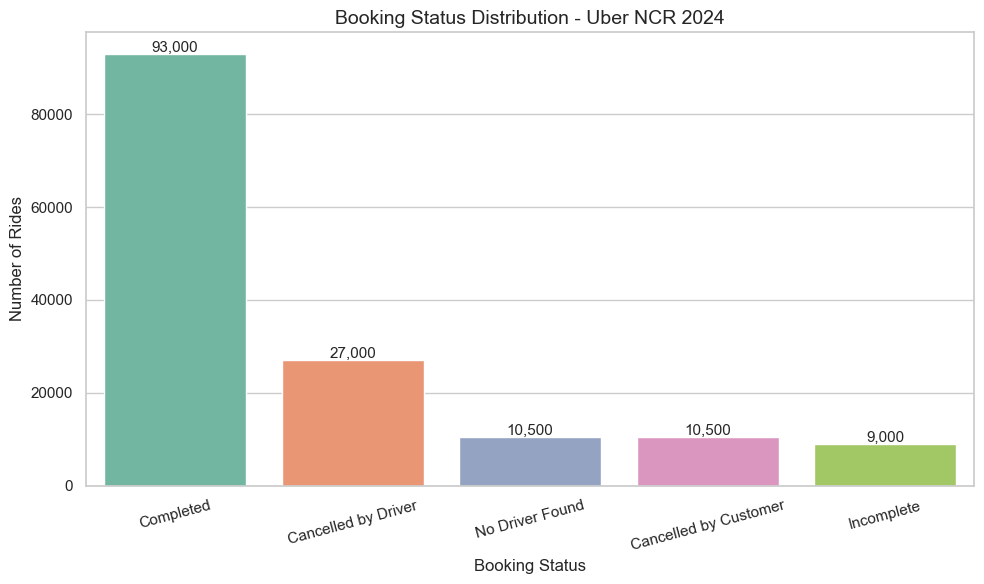

In [ ]:
# Booking status distribution visualization 
plt.figure(figsize=(10, 6))
sns.barplot(x=status_counts.index, y=status_counts.values, palette='Set2')
plt.title('Booking Status Distribution - Uber NCR 2024', fontsize=14)
plt.xlabel('Booking Status')
plt.ylabel('Number of Rides')
plt.xticks(rotation=15)

for i, v in enumerate(status_counts.values):
    plt.text(i, v + 500, f'{v:,}', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('../outputs/booking_status_distribution.png', dpi=150)
plt.show()

## Section 2: Monthly Booking Trends

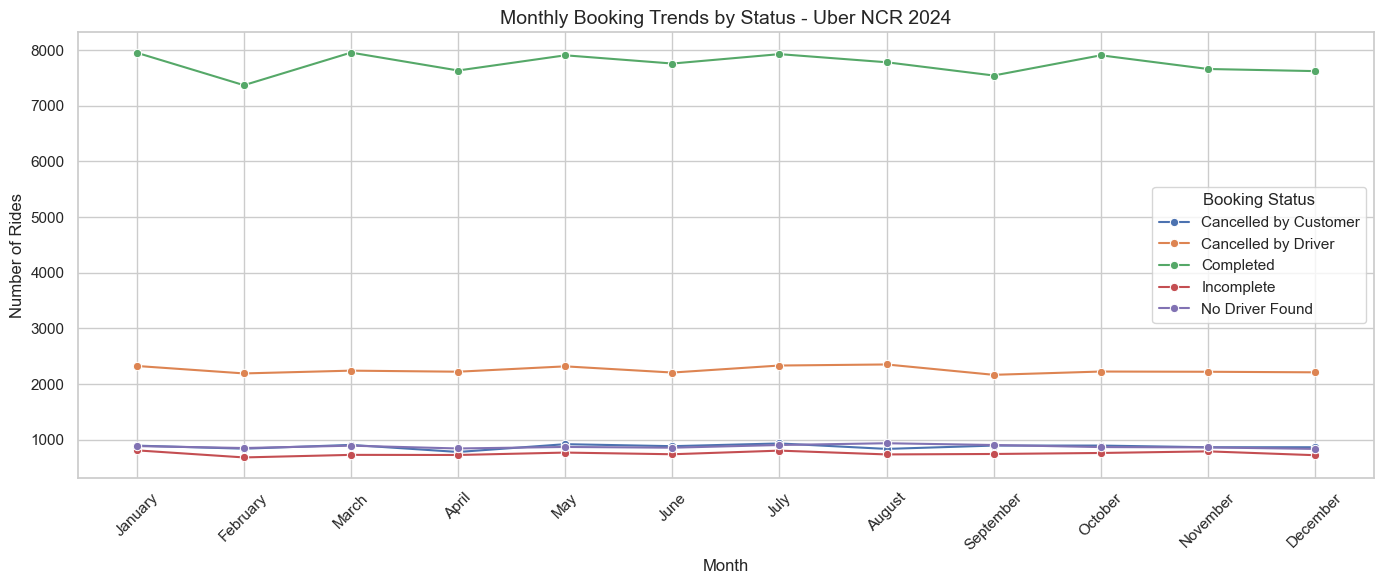

In [ ]:
# Monthly booking trends

month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
# Convert Month column to ordered categorical to ensure chronological sorting
if 'Month' in df.columns:
    df['Month'] = pd.Categorical(df['Month'], categories=month_order, ordered=True)

monthly = df.groupby(['Month', 'Booking Status']).size().reset_index(name='Count')
monthly = monthly.sort_values('Month')

plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly, x='Month', y='Count', hue='Booking Status', marker='o')
plt.title('Monthly Booking Trends by Status - Uber NCR 2024', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Number of Rides')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/monthly_trends.png', dpi=150)
plt.show()


## Section 3: Cancellation Analysis

/var/folders/3_/bt59q6lx6_3fykq6by6cp_d80000gn/T/ipykernel_76821/3946069681.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=customer_cancel.values, y=customer_cancel.index, palette='Oranges_r')


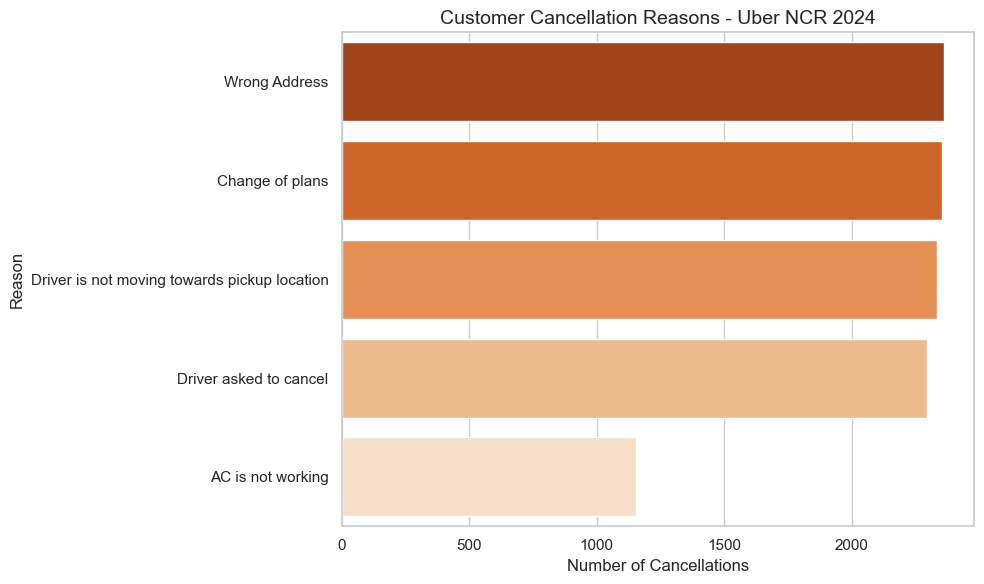

In [10]:
# Cancellation reasons by customer
customer_cancel = df['Reason for cancelling by Customer'].value_counts().dropna()

plt.figure(figsize=(10, 6))
sns.barplot(x=customer_cancel.values, y=customer_cancel.index, palette='Oranges_r')
plt.title('Customer Cancellation Reasons - Uber NCR 2024', fontsize=14)
plt.xlabel('Number of Cancellations')
plt.ylabel('Reason')
plt.tight_layout()
plt.savefig('../outputs/customer_cancellation_reasons.png', dpi=150)
plt.show()

/var/folders/3_/bt59q6lx6_3fykq6by6cp_d80000gn/T/ipykernel_76821/1494603129.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=driver_cancel.values, y=driver_cancel.index, palette='Blues_r')


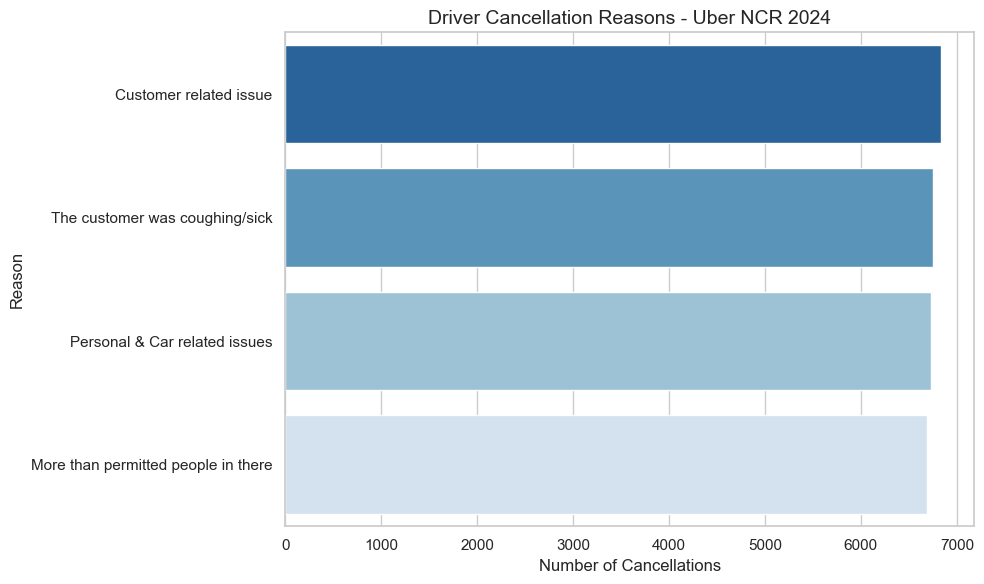

In [11]:
# Driver cancellation reasons
driver_cancel = df['Driver Cancellation Reason'].value_counts().dropna()

plt.figure(figsize=(10, 6))
sns.barplot(x=driver_cancel.values, y=driver_cancel.index, palette='Blues_r')
plt.title('Driver Cancellation Reasons - Uber NCR 2024', fontsize=14)
plt.xlabel('Number of Cancellations')
plt.ylabel('Reason')
plt.tight_layout()
plt.savefig('../outputs/driver_cancellation_reasons.png', dpi=150)
plt.show()

/var/folders/3_/bt59q6lx6_3fykq6by6cp_d80000gn/T/ipykernel_76821/781784545.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vehicle_cancel.values, y=vehicle_cancel.index, palette='Reds_r')


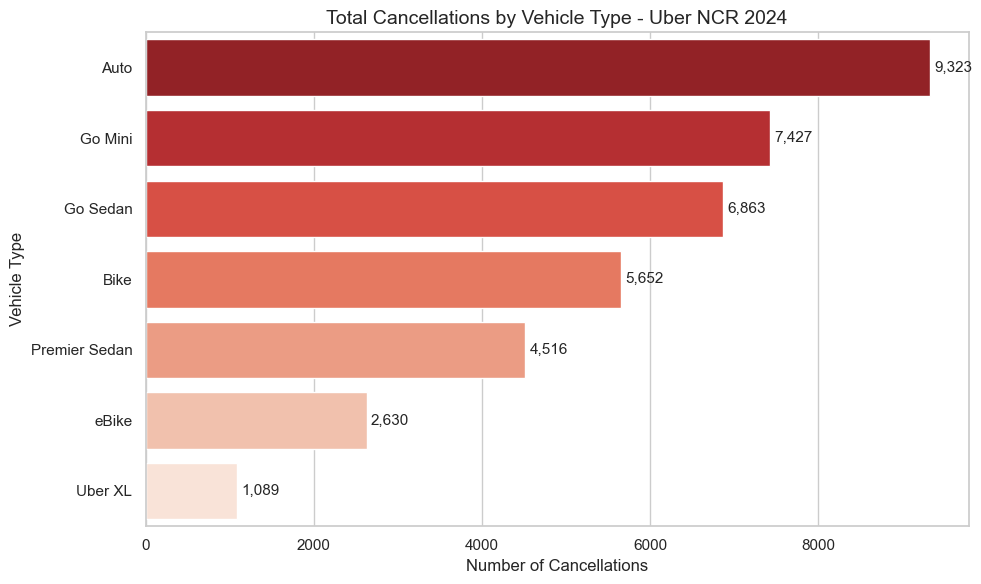

In [15]:
# Cancellations by vehicle type
vehicle_cancel = df[df['Booking Status'].isin(['Cancelled by Driver', 'Cancelled by Customer'])]\
    .groupby('Vehicle Type')['Booking Status'].count().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=vehicle_cancel.values, y=vehicle_cancel.index, palette='Reds_r')
plt.title('Total Cancellations by Vehicle Type - Uber NCR 2024', fontsize=14)
plt.xlabel('Number of Cancellations')
plt.ylabel('Vehicle Type')
for i, v in enumerate(vehicle_cancel.values):
    plt.text(v + 50, i, f'{v:,}', va='center', fontsize=11)
plt.tight_layout()
plt.savefig('../outputs/cancellations_by_vehicle.png', dpi=150)
plt.show()

/var/folders/3_/bt59q6lx6_3fykq6by6cp_d80000gn/T/ipykernel_76821/2344129344.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vehicle_bookings.values, y=vehicle_bookings.index, palette='Blues_r')


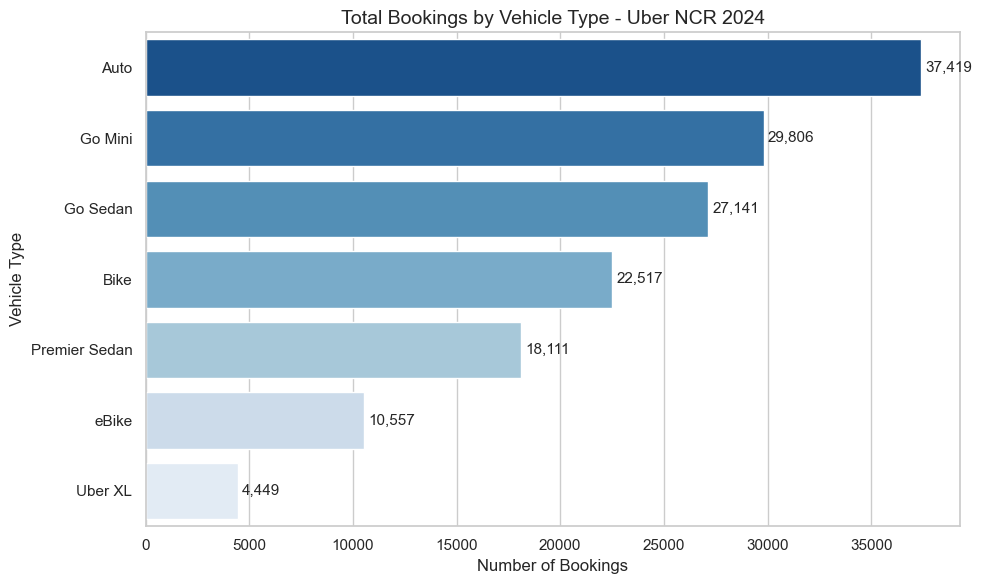

In [14]:
# Total bookings by vehicle type
vehicle_bookings = df.groupby('Vehicle Type').size().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=vehicle_bookings.values, y=vehicle_bookings.index, palette='Blues_r')
plt.title('Total Bookings by Vehicle Type - Uber NCR 2024', fontsize=14)
plt.xlabel('Number of Bookings')
plt.ylabel('Vehicle Type')
for i, v in enumerate(vehicle_bookings.values):
    plt.text(v + 200, i, f'{v:,}', va='center', fontsize=11)
plt.tight_layout()
plt.savefig('../outputs/bookings_by_vehicle.png', dpi=150)
plt.show()

/var/folders/3_/bt59q6lx6_3fykq6by6cp_d80000gn/T/ipykernel_76821/4090505273.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cancel_rate.values, y=cancel_rate.index, palette='Reds_r')


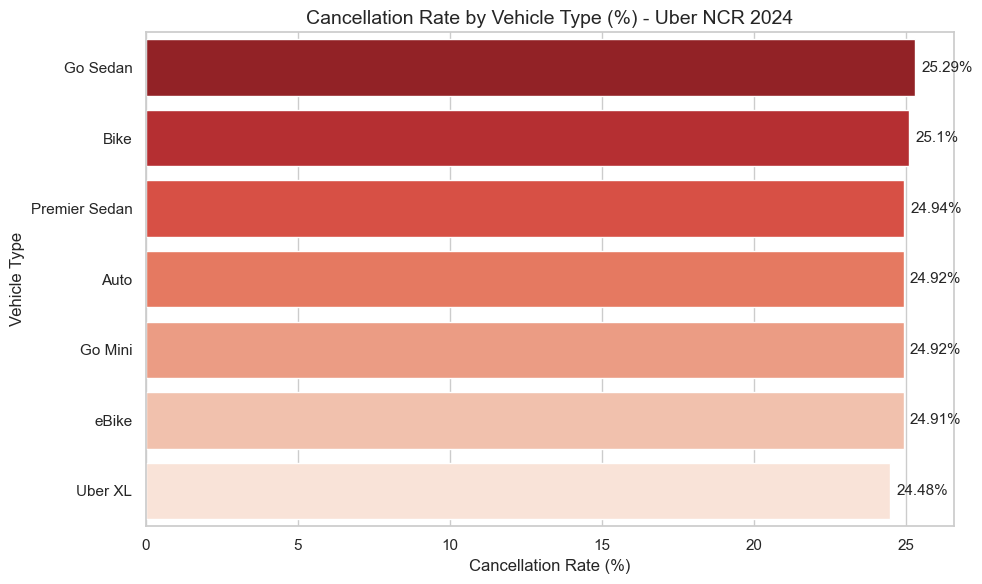

In [13]:
# Cancellation rate by vehicle type (percentage)
total_by_vehicle = df.groupby('Vehicle Type').size()
cancelled_by_vehicle = df[df['Booking Status'].isin(['Cancelled by Driver', 'Cancelled by Customer'])]\
    .groupby('Vehicle Type').size()

cancel_rate = (cancelled_by_vehicle / total_by_vehicle * 100).round(2).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=cancel_rate.values, y=cancel_rate.index, palette='Reds_r')
plt.title('Cancellation Rate by Vehicle Type (%) - Uber NCR 2024', fontsize=14)
plt.xlabel('Cancellation Rate (%)')
plt.ylabel('Vehicle Type')
for i, v in enumerate(cancel_rate.values):
    plt.text(v + 0.2, i, f'{v}%', va='center', fontsize=11)
plt.tight_layout()
plt.savefig('../outputs/cancellation_rate_by_vehicle.png', dpi=150)
plt.show()

## Section 4: Revenue Analysis

In [16]:
# Total revenue from completed rides only
total_revenue = completed['Booking Value'].sum()
avg_fare = completed['Booking Value'].mean()
avg_distance = completed['Ride Distance'].mean()

print(f"Total Revenue (Completed Rides): ₹{total_revenue:,.0f}")
print(f"Average Fare per Ride: ₹{avg_fare:,.0f}")
print(f"Average Ride Distance: {avg_distance:.2f} km")
print(f"Average Fare per KM: ₹{(avg_fare/avg_distance):.2f}")

Total Revenue (Completed Rides): ₹47,260,574
Average Fare per Ride: ₹508
Average Ride Distance: 26.00 km
Average Fare per KM: ₹19.54


In [17]:
# Revenue breakdown by vehicle type
vehicle_revenue = completed.groupby('Vehicle Type').agg(
    Total_Revenue=('Booking Value', 'sum'),
    Avg_Fare=('Booking Value', 'mean'),
    Avg_Distance=('Ride Distance', 'mean'),
    Total_Rides=('Booking Value', 'count')
).round(2).sort_values('Total_Revenue', ascending=False)

vehicle_revenue['Fare_per_KM'] = (vehicle_revenue['Avg_Fare'] / vehicle_revenue['Avg_Distance']).round(2)

print(vehicle_revenue)

               Total_Revenue  Avg_Fare  Avg_Distance  Total_Rides  Fare_per_KM
Vehicle Type                                                                  
Auto              11727615.0    506.48         25.99        23155        19.49
Go Mini            9411418.0    507.38         25.99        18549        19.52
Go Sedan           8538560.0    512.03         25.98        16676        19.71
Bike               7144913.0    509.11         26.00        14034        19.58
Premier Sedan      5733655.0    509.57         25.95        11252        19.64
eBike              3298157.0    503.46         26.34         6551        19.11
Uber XL            1406256.0    505.30         25.72         2783        19.65


/var/folders/3_/bt59q6lx6_3fykq6by6cp_d80000gn/T/ipykernel_76821/2151899680.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vehicle_revenue['Total_Revenue'], y=vehicle_revenue.index, palette='Greens_r', ax=axes[0])
/var/folders/3_/bt59q6lx6_3fykq6by6cp_d80000gn/T/ipykernel_76821/2151899680.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vehicle_revenue['Avg_Fare'], y=vehicle_revenue.index, palette='Greens_r', ax=axes[1])
/var/folders/3_/bt59q6lx6_3fykq6by6cp_d80000gn/T/ipykernel_76821/2151899680.py:18: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3_/bt59q6lx6_3fykq6by6cp_d80000gn/T/ipykernel_76821/2151899680.py:1

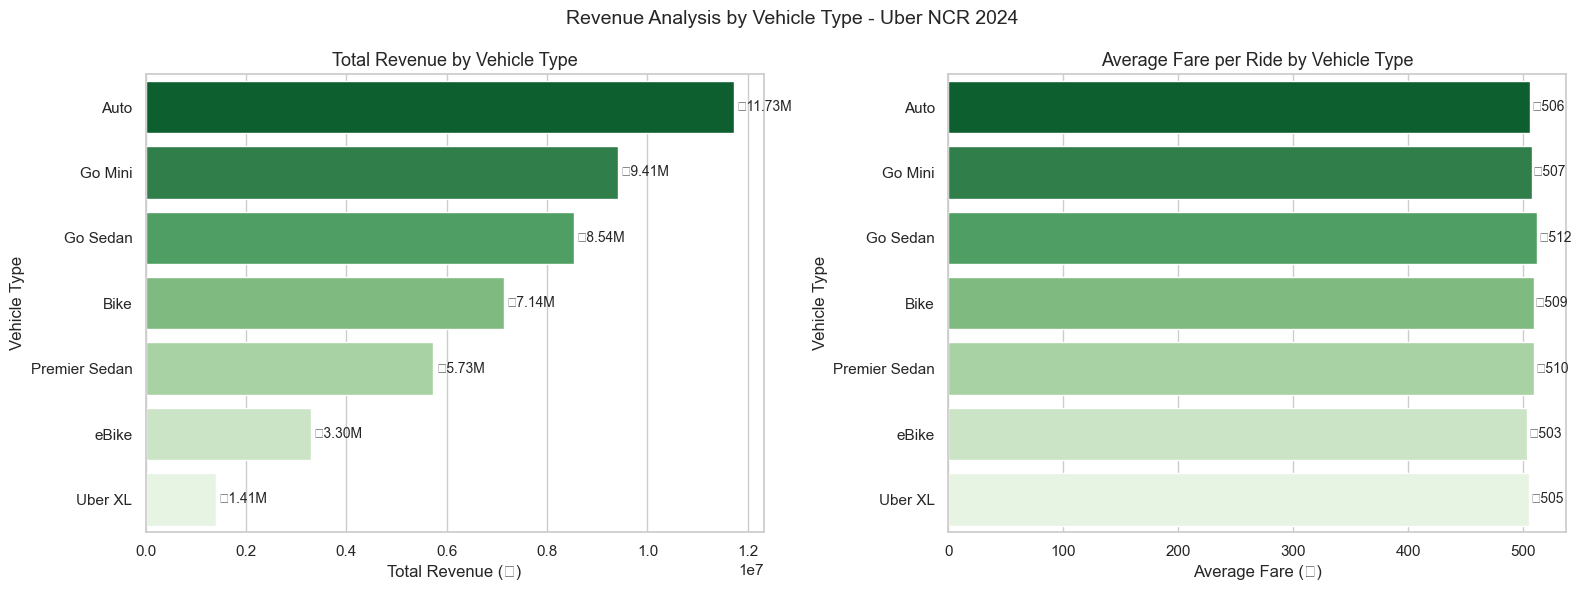

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Total revenue by vehicle type
sns.barplot(x=vehicle_revenue['Total_Revenue'], y=vehicle_revenue.index, palette='Greens_r', ax=axes[0])
axes[0].set_title('Total Revenue by Vehicle Type', fontsize=13)
axes[0].set_xlabel('Total Revenue (₹)')
for i, v in enumerate(vehicle_revenue['Total_Revenue']):
    axes[0].text(v + 50000, i, f'₹{v/1e6:.2f}M', va='center', fontsize=10)

# Average fare by vehicle type
sns.barplot(x=vehicle_revenue['Avg_Fare'], y=vehicle_revenue.index, palette='Greens_r', ax=axes[1])
axes[1].set_title('Average Fare per Ride by Vehicle Type', fontsize=13)
axes[1].set_xlabel('Average Fare (₹)')
for i, v in enumerate(vehicle_revenue['Avg_Fare']):
    axes[1].text(v + 1, i, f'₹{v:.0f}', va='center', fontsize=10)

plt.suptitle('Revenue Analysis by Vehicle Type - Uber NCR 2024', fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/revenue_by_vehicle.png', dpi=150)
plt.show()

In [19]:
# Estimated revenue lost to cancellations
# We use the average fare from completed rides as the estimate per lost ride
avg_fare = completed['Booking Value'].mean()

cancelled = df[df['Booking Status'].isin(['Cancelled by Driver', 'Cancelled by Customer', 'No Driver Found', 'Incomplete'])]

lost_revenue = len(cancelled) * avg_fare

print(f"Total Lost Bookings: {len(cancelled):,}")
print(f"Average Fare per Completed Ride: ₹{avg_fare:,.0f}")
print(f"Estimated Revenue Lost: ₹{lost_revenue:,.0f}")
print(f"That is ₹{lost_revenue/1e6:.2f} Million lost")
print(f"As % of potential total revenue: {(lost_revenue/(total_revenue+lost_revenue)*100):.1f}%")

Total Lost Bookings: 57,000
Average Fare per Completed Ride: ₹508
Estimated Revenue Lost: ₹28,966,158
That is ₹28.97 Million lost
As % of potential total revenue: 38.0%


/var/folders/3_/bt59q6lx6_3fykq6by6cp_d80000gn/T/ipykernel_76821/2954626454.py:13: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3_/bt59q6lx6_3fykq6by6cp_d80000gn/T/ipykernel_76821/2954626454.py:14: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.savefig('../outputs/revenue_earned_vs_lost.png', dpi=150)


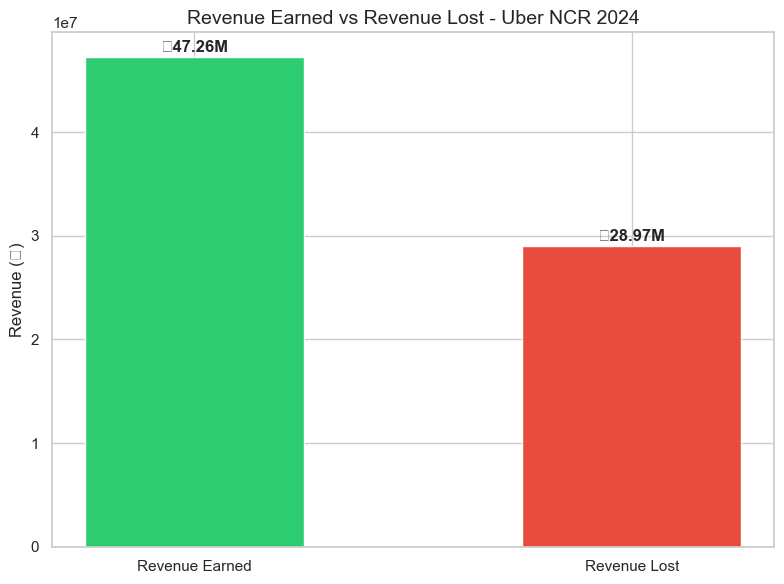

In [20]:
# Revenue earned vs lost
labels = ['Revenue Earned', 'Revenue Lost']
values = [total_revenue, lost_revenue]
colors = ['#2ecc71', '#e74c3c']

plt.figure(figsize=(8, 6))
bars = plt.bar(labels, values, color=colors, width=0.5)
plt.title('Revenue Earned vs Revenue Lost - Uber NCR 2024', fontsize=14)
plt.ylabel('Revenue (₹)')
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 500000, 
             f'₹{val/1e6:.2f}M', ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/revenue_earned_vs_lost.png', dpi=150)
plt.show()

## Section 5: Customer Experience - Ratings Analysis

In [21]:
# Average driver and customer ratings by vehicle type
ratings = completed.groupby('Vehicle Type').agg(
    Avg_Driver_Rating=('Driver Ratings', 'mean'),
    Avg_Customer_Rating=('Customer Rating', 'mean')
).round(2)

print(ratings)

               Avg_Driver_Rating  Avg_Customer_Rating
Vehicle Type                                         
Auto                        4.23                 4.40
Bike                        4.23                 4.40
Go Mini                     4.23                 4.40
Go Sedan                    4.23                 4.41
Premier Sedan               4.23                 4.40
Uber XL                     4.24                 4.40
eBike                       4.23                 4.40


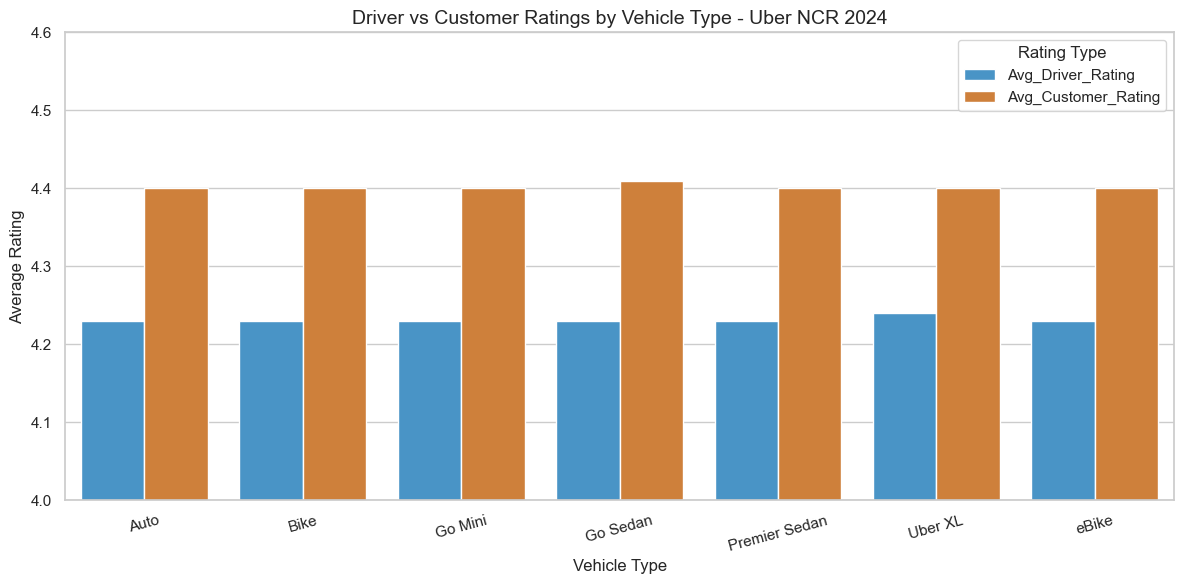

In [22]:
# Ratings comparison by vehicle type
ratings_melted = ratings.reset_index().melt(id_vars='Vehicle Type', 
                                             var_name='Rating Type', 
                                             value_name='Rating')

plt.figure(figsize=(12, 6))
sns.barplot(data=ratings_melted, x='Vehicle Type', y='Rating', hue='Rating Type', palette=['#3498db', '#e67e22'])
plt.title('Driver vs Customer Ratings by Vehicle Type - Uber NCR 2024', fontsize=14)
plt.xlabel('Vehicle Type')
plt.ylabel('Average Rating')
plt.ylim(4.0, 4.6)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('../outputs/ratings_by_vehicle.png', dpi=150)
plt.show()

## Section 6: Payment Behavior Analysis

In [23]:
# Payment method distribution
payment = completed.groupby('Payment Method').agg(
    Total_Rides=('Booking Value', 'count'),
    Total_Revenue=('Booking Value', 'sum')
).round(2).sort_values('Total_Revenue', ascending=False)

payment['Revenue_Percentage'] = (payment['Total_Revenue'] / payment['Total_Revenue'].sum() * 100).round(2)

print(payment)

                Total_Rides  Total_Revenue  Revenue_Percentage
Payment Method                                                
UPI                   41834     21274591.0               45.02
Cash                  23114     11756071.0               24.88
Uber Wallet           11206      5669070.0               12.00
Credit Card            9320      4753767.0               10.06
Debit Card             7526      3807075.0                8.06


/var/folders/3_/bt59q6lx6_3fykq6by6cp_d80000gn/T/ipykernel_76821/1456509271.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=payment['Total_Revenue'], y=payment.index, palette='Purples_r', ax=axes[0])
/var/folders/3_/bt59q6lx6_3fykq6by6cp_d80000gn/T/ipykernel_76821/1456509271.py:17: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3_/bt59q6lx6_3fykq6by6cp_d80000gn/T/ipykernel_76821/1456509271.py:18: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.savefig('../outputs/payment_analysis.png', dpi=150)
/opt/anaconda3/envs/uber-analytics/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


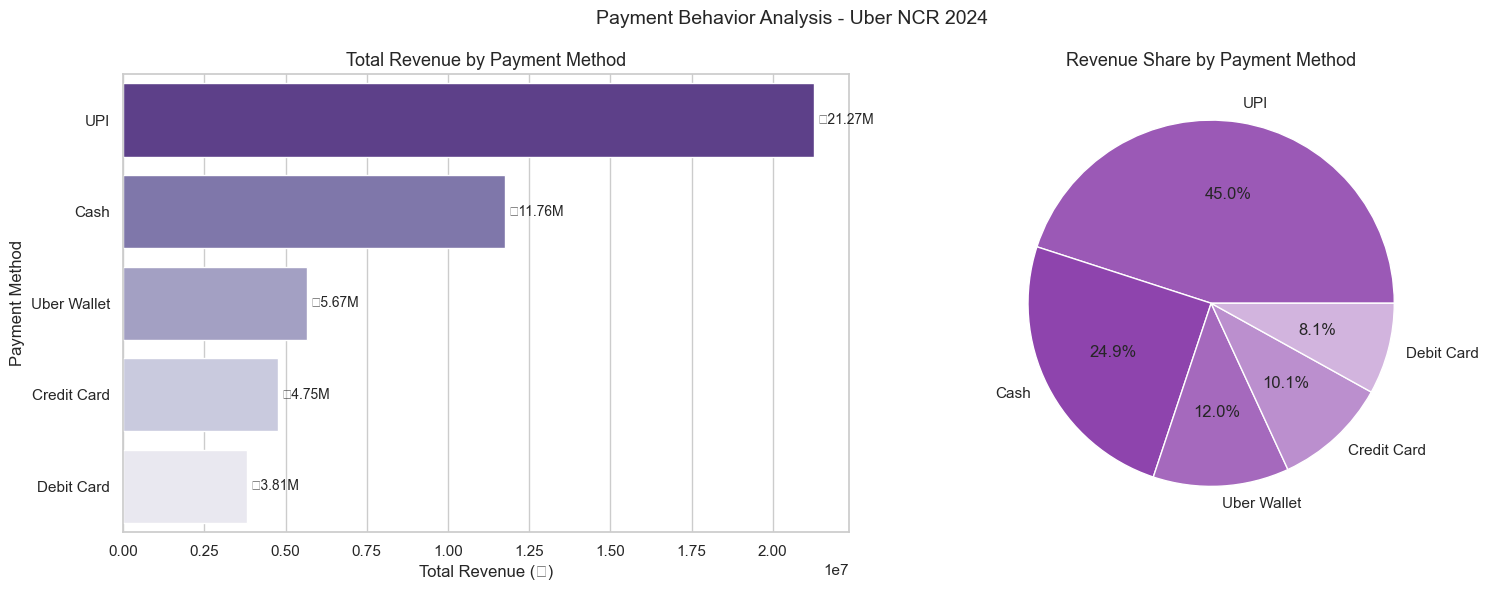

In [24]:
# Payment method visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Revenue by payment method
sns.barplot(x=payment['Total_Revenue'], y=payment.index, palette='Purples_r', ax=axes[0])
axes[0].set_title('Total Revenue by Payment Method', fontsize=13)
axes[0].set_xlabel('Total Revenue (₹)')
for i, v in enumerate(payment['Total_Revenue']):
    axes[0].text(v + 100000, i, f'₹{v/1e6:.2f}M', va='center', fontsize=10)

# Revenue percentage pie chart
axes[1].pie(payment['Revenue_Percentage'], labels=payment.index, 
            autopct='%1.1f%%', colors=['#9b59b6','#8e44ad','#a569bd','#bb8fce','#d2b4de'])
axes[1].set_title('Revenue Share by Payment Method', fontsize=13)

plt.suptitle('Payment Behavior Analysis - Uber NCR 2024', fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/payment_analysis.png', dpi=150)
plt.show()

## Section 7: Location Analysis

In [25]:
# Check unique locations
pickup_locations = df['Pickup Location'].unique()
print(f"Total unique pickup locations: {len(pickup_locations)}")
print(pickup_locations)

Total unique pickup locations: 176
<StringArray>
[        'Palam Vihar',       'Shastri Nagar',             'Khandsa',
 'Central Secretariat',    'Ghitorni Village',               'AIIMS',
            'Vaishali',         'Mayur Vihar',     'Noida Sector 62',
              'Rohini',
 ...
  'Bhikaji Cama Place',         'Kirti Nagar',           'Paharganj',
       'Subhash Nagar',         'Old Gurgaon',         'Udyog Vihar',
           'Hauz Khas',       'Paschim Vihar',       'Ambience Mall',
           'Lal Quila']
Length: 176, dtype: str


In [26]:
# Install geopy
import subprocess
subprocess.run(['pip', 'install', 'geopy'])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [geopy]


CompletedProcess(args=['pip', 'install', 'geopy'], returncode=0)

In [29]:
# Fetch coordinates for all unique locations using New Delhi context
unique_locations = df['Pickup Location'].unique().tolist()

location_coords = {}
for loc in unique_locations:
    try:
        result = geocode(f"{loc}, New Delhi, India")
        if result:
            location_coords[loc] = (result.latitude, result.longitude)
            print(f"✓ {loc}")
        else:
            location_coords[loc] = (None, None)
            print(f"✗ {loc}: Not found")
    except Exception as e:
        location_coords[loc] = (None, None)
        print(f"✗ {loc}: Error")

print(f"\nTotal found: {sum(1 for v in location_coords.values() if v[0] is not None)}/{len(unique_locations)}")

✓ Palam Vihar
✓ Shastri Nagar
✗ Khandsa: Not found
✓ Central Secretariat
✓ Ghitorni Village
✓ AIIMS
✗ Vaishali: Not found
✗ Mayur Vihar: Not found
✓ Noida Sector 62
✓ Rohini
✓ Udyog Bhawan
✗ Vidhan Sabha: Not found
✓ Patel Chowk
✗ Malviya Nagar: Not found
✗ Madipur: Not found
✓ Jama Masjid
✓ IGI Airport
✗ Vinobapuri: Not found
✗ Kashmere Gate: Not found
✓ Pitampura
✓ Punjabi Bagh
✗ Greater Noida: Not found
✗ Tis Hazari: Not found
✗ Noida Sector 18: Not found
✗ Kanhaiya Nagar: Not found
✓ Okhla
✗ Cyber Hub: Not found
✗ Sadar Bazar Gurgaon: Not found
✓ Shastri Park
✗ Faridabad Sector 15: Not found
✗ Qutub Minar: Not found
✗ Mundka: Not found
✗ DLF City Court: Not found
✓ New Colony
✗ Nirman Vihar: Not found
✓ New Delhi Railway Station
✗ Civil Lines Gurgaon: Not found
✗ Seelampur: Not found
✗ Noida Extension: Not found
✓ Adarsh Nagar
✗ Panipat: Not found
✓ Karol Bagh
✓ Sultanpur
✓ Moti Nagar
✓ Dilshad Garden
✓ Aya Nagar
✓ Rajiv Chowk
✓ MG Road
✗ Jasola: Not found
✗ Ardee City: Not found
✓

In [30]:
# Retry failed locations with broader context
failed = [loc for loc, coords in location_coords.items() if coords[0] is None]
print(f"Retrying {len(failed)} locations...")

for loc in failed:
    try:
        # Try with just India as context
        result = geocode(f"{loc}, Haryana, India") or \
                 geocode(f"{loc}, Uttar Pradesh, India") or \
                 geocode(f"{loc}, NCR, India")
        if result:
            location_coords[loc] = (result.latitude, result.longitude)
            print(f"✓ {loc}")
        else:
            print(f"✗ {loc}: Still not found")
    except:
        print(f"✗ {loc}: Error")

print(f"\nTotal found after retry: {sum(1 for v in location_coords.values() if v[0] is not None)}/{len(unique_locations)}")

Retrying 86 locations...
✓ Khandsa
✓ Vaishali
✗ Mayur Vihar: Still not found
✓ Vidhan Sabha
✓ Malviya Nagar
✗ Madipur: Still not found
✗ Vinobapuri: Still not found
✗ Kashmere Gate: Still not found
✓ Greater Noida
✗ Tis Hazari: Still not found
✓ Noida Sector 18
✓ Kanhaiya Nagar
✓ Cyber Hub
✓ Sadar Bazar Gurgaon
✓ Faridabad Sector 15
✗ Qutub Minar: Still not found
✗ Mundka: Still not found
✓ DLF City Court
✗ Nirman Vihar: Still not found
✓ Civil Lines Gurgaon
✗ Seelampur: Still not found
✓ Noida Extension
✓ Panipat
✗ Jasola: Still not found
✓ Ardee City
✗ Anand Vihar ISBT: Still not found
✗ Dwarka Mor: Still not found
✓ Rajiv Nagar
✓ Sohna Road
✓ Bahadurgarh
✗ INA Market: Still not found
✓ Sushant Lok
✓ IGNOU Road
✓ IMT Manesar
✗ Azadpur: Still not found
✓ Sikanderpur
✗ Kashmere Gate ISBT: Still not found
✗ Kherki Daula Toll: Still not found
✓ IFFCO Chowk
✗ Hauz Rani: Still not found
✗ Sarai Kale Khan: Still not found
✗ Maidan Garhi: Still not found
✓ Yamuna Bank
✓ Mansarovar Park
✓ Rit

In [31]:
# Convert coordinates dictionary to dataframe
coords_df = pd.DataFrame([
    {'Location': loc, 'Latitude': coords[0], 'Longitude': coords[1]}
    for loc, coords in location_coords.items()
])

# Merge coordinates into main dataframe for pickup locations
df = df.merge(coords_df.rename(columns={
    'Location': 'Pickup Location',
    'Latitude': 'Pickup Lat',
    'Longitude': 'Pickup Lng'
}), on='Pickup Location', how='left')

# Merge coordinates for drop locations
df = df.merge(coords_df.rename(columns={
    'Location': 'Drop Location',
    'Latitude': 'Drop Lat',
    'Longitude': 'Drop Lng'
}), on='Drop Location', how='left')

print(df[['Pickup Location', 'Pickup Lat', 'Pickup Lng']].head(10))
print(f"\nRows with coordinates: {df['Pickup Lat'].notna().sum()}")

       Pickup Location  Pickup Lat  Pickup Lng
0          Palam Vihar   28.570786   77.163424
1        Shastri Nagar   28.644279   77.271886
2              Khandsa   28.453328   77.019540
3  Central Secretariat   28.615879   77.212282
4     Ghitorni Village   28.493121   77.142487
5                AIIMS   28.569380   77.206551
6             Vaishali   28.493018   77.326079
7          Mayur Vihar         NaN         NaN
8      Noida Sector 62   28.579389   77.293387
9               Rohini   28.719436   77.067235

Rows with coordinates: 122775


In [32]:
# Export final dataset with coordinates for Power BI
df.to_csv('../data/uber_powerbi.csv', index=False)
print("Export successful")
print(f"Total rows: {len(df)}")
print(f"Total columns: {len(df.columns)}")
print(df.columns.tolist())

Export successful
Total rows: 150000
Total columns: 27
['Date', 'Time', 'Booking ID', 'Booking Status', 'Customer ID', 'Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT', 'Avg CTAT', 'Cancelled Rides by Customer', 'Reason for cancelling by Customer', 'Cancelled Rides by Driver', 'Driver Cancellation Reason', 'Incomplete Rides', 'Incomplete Rides Reason', 'Booking Value', 'Ride Distance', 'Driver Ratings', 'Customer Rating', 'Payment Method', 'Month', 'Hour', 'Pickup Lat', 'Pickup Lng', 'Drop Lat', 'Drop Lng']


In [ ]:
git add .
git commit -m "Add geocoded coordinates and Power BI dataset"
git push origin main

SyntaxError: invalid syntax (2864688101.py, line 1)